Gaussian Process Regressor RMSE on validation set: 2.7263


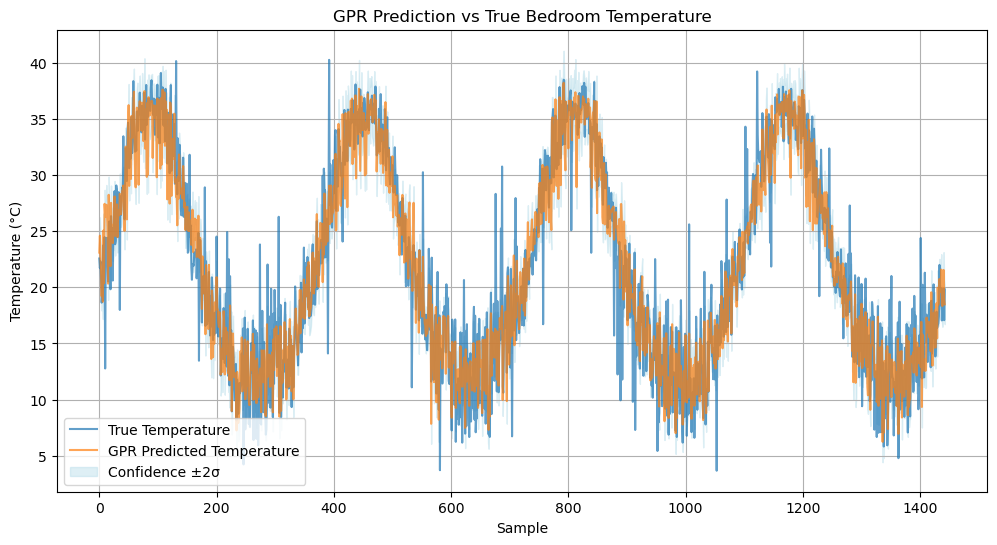

Gaussian Process Regressor RMSE on validation set: 2.8674


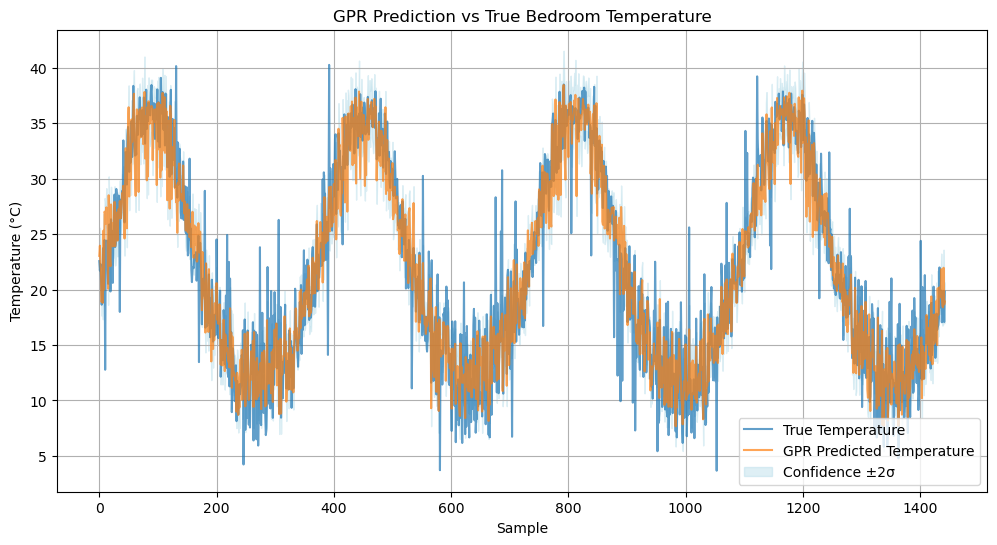

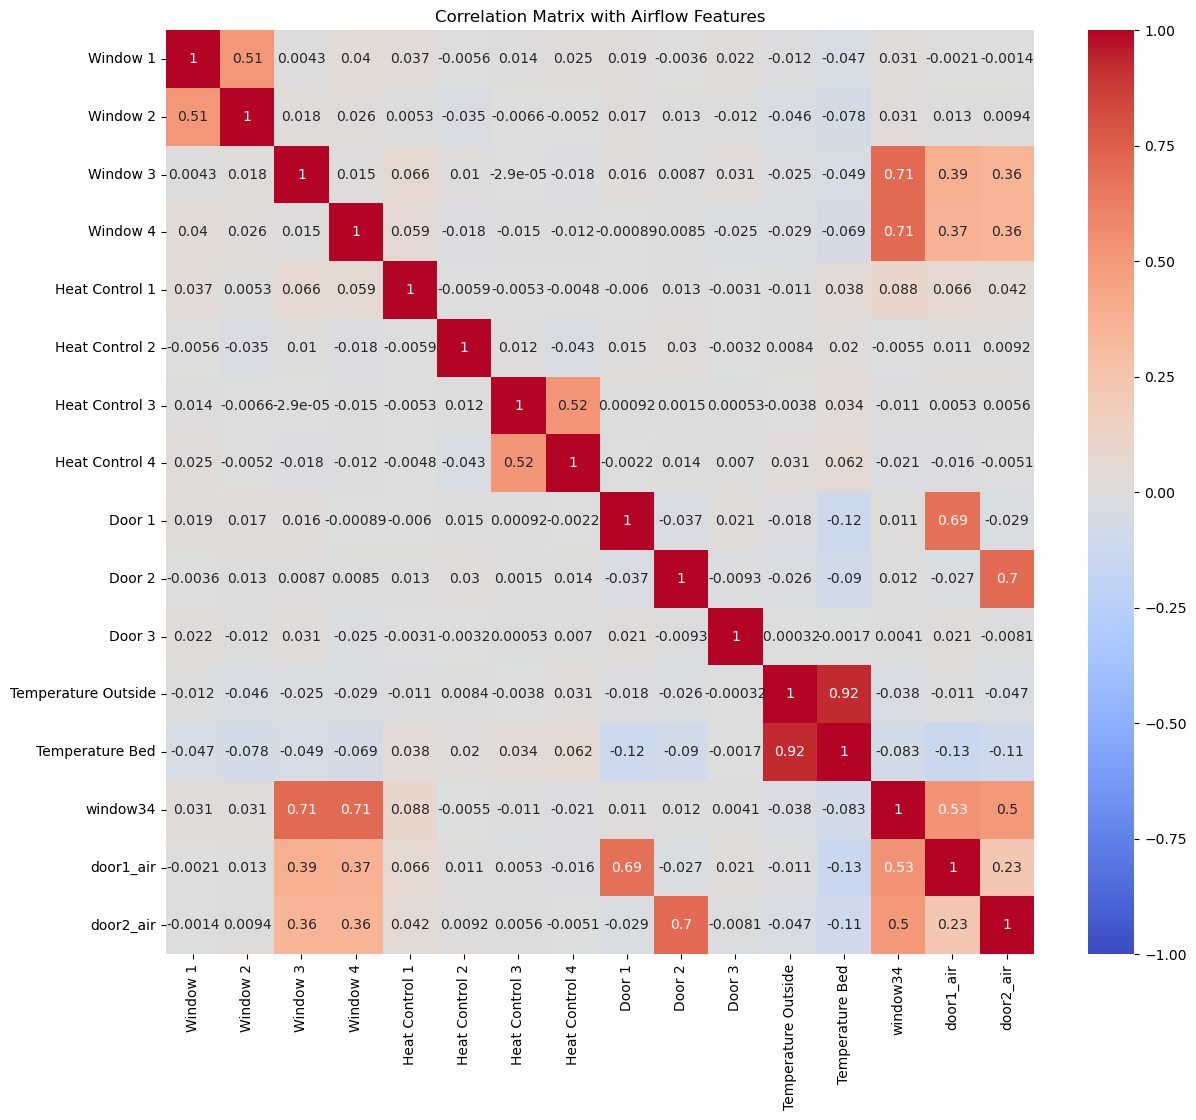

<Figure size 1200x1200 with 0 Axes>

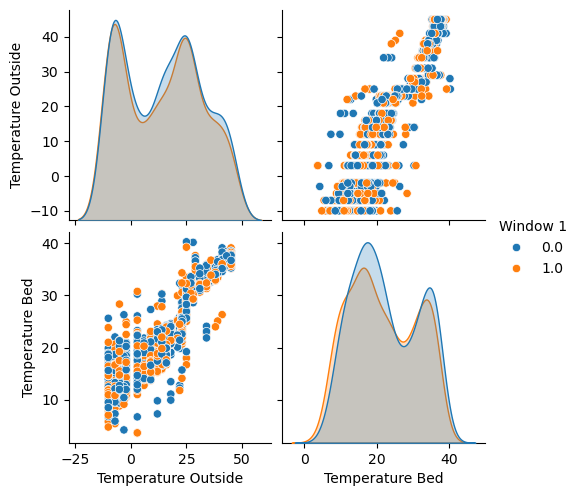

<Figure size 1200x1200 with 0 Axes>

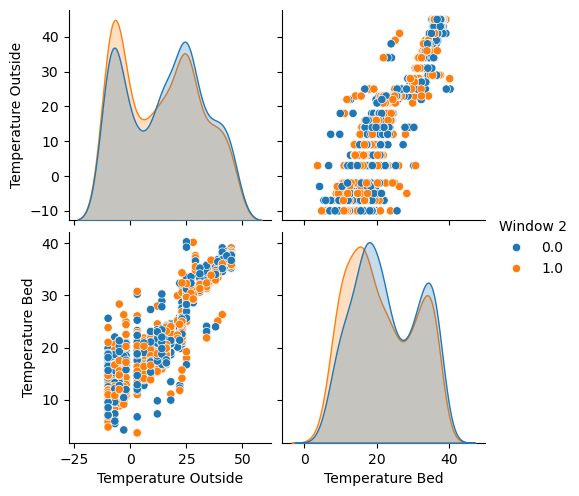

<Figure size 1200x1200 with 0 Axes>

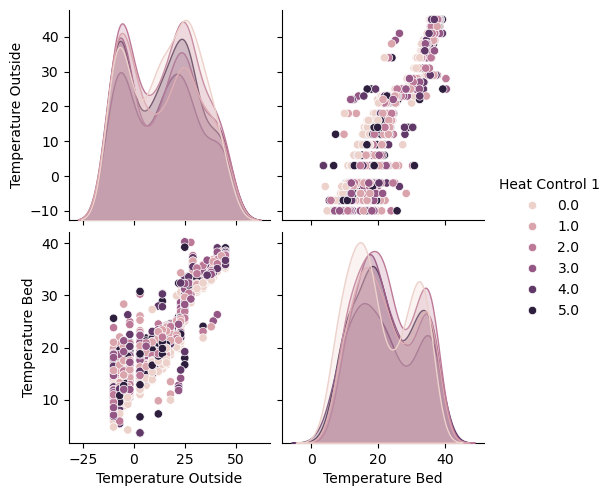

<Figure size 1200x1200 with 0 Axes>

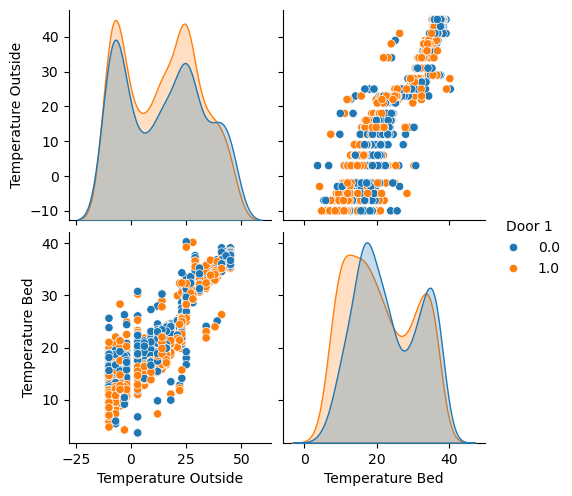

<Figure size 1200x1200 with 0 Axes>

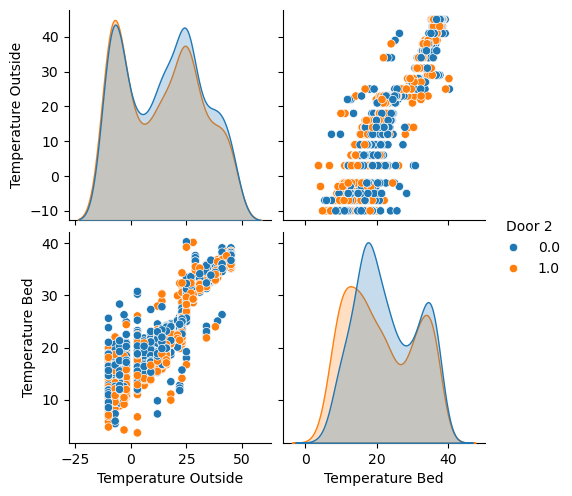

<Figure size 1200x1200 with 0 Axes>

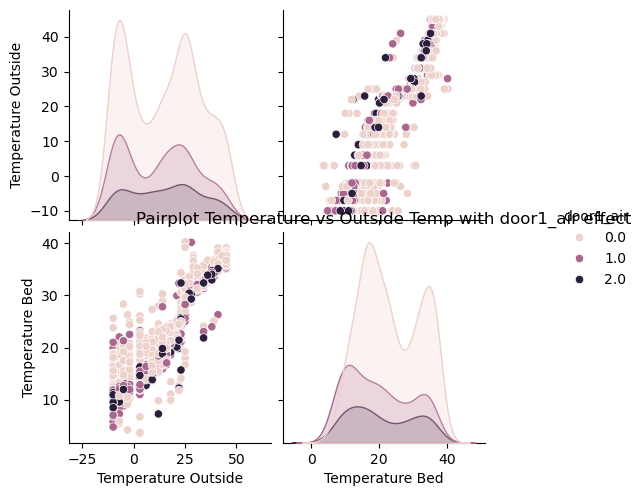

<Figure size 1200x1200 with 0 Axes>

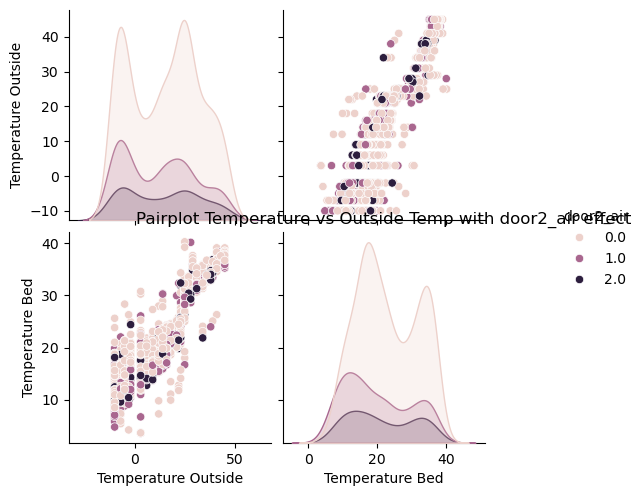

In [14]:
import numpy as np
import pandas as pd
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from sklearn.metrics import mean_squared_error
%matplotlib inline
import seaborn as sns

# --- Load the data
data_train_Temperature = pd.read_csv('data_train_Temperature.csv')
data_test_Temperature = pd.read_csv('data_test_Temperature.csv')

# Map outside temperature adjectives to numbers
adjective_to_temperature = {
    "Freezing": -10, "Icy": -7, "Frigid": -5, "Brrrr": -3, "Bitter": -2,
    "Chilly": 3, "Brisk": 6, "Cool": 9, "Crisp": 12, "Fresh": 14, "Mild": 16,
    "Pleasant": 18, "Temperate": 21, "Ideal": 22, "Comfortable": 23, "Warm": 25,
    "Toasty": 27, "Balmy": 28, "Tropical": 29, "Hot": 31, "Sultry": 34,
    "Scorching": 36, "Blistering": 38, "Sweltering": 39, "Boiling": 41,
    "Burning": 43, "Infernal": 45
}

for k in range(len(data_train_Temperature)):
    data_train_Temperature.loc[k, "Temperature Outside"] = adjective_to_temperature[data_train_Temperature.loc[k, "Temperature Outside"]]

for k in range(len(data_test_Temperature)):
    data_test_Temperature.loc[k, "Temperature Outside"] = adjective_to_temperature[data_test_Temperature.loc[k, "Temperature Outside"]]

# --- Cleaning outliers
mean = data_train_Temperature.values[:, 12].mean()
std = data_train_Temperature.values[:, 12].std()
data_train_Temperature_clean = data_train_Temperature[np.abs(data_train_Temperature.values[:, 12] - mean) < 2 * std]

# --- Train/Validation split
observations = data_train_Temperature_clean.shape[0]
to_drop = data_train_Temperature_clean.index[range(0, int(0.2*observations))]
train_data_set = data_train_Temperature_clean.values[range(0, int(0.2*observations)), :]
validation_set = data_train_Temperature_clean.values[range(int(0.2*observations), observations), :]

#observations = data_train_Temperature_clean.shape[0]
#to_drop = data_train_Temperature_clean.index[range(0, int(0.2*observations))]
#validation_set = data_train_Temperature_clean.values[range(0, int(0.2*observations)), :]
#train_data_set = data_train_Temperature_clean.values[range(int(0.2*observations), observations), :]

def add_custom_features(data):
    X = data.copy()
    
    window1, window2, window3, window4 = X[:,0], X[:,1], X[:,2], X[:,3]
    door1, door2, door3 = X[:,8], X[:,9], X[:,10]
    
    window34 = window3 + window4 
    window12 = window1 + window2
    door1_air = door1 * window34
    door2_air = door2 * window12

    new_features = np.vstack([door1_air, door2_air]).T
    X_augmented = np.hstack([X[:, :-1], new_features, X[:, -1:]])  # Insert new features before target

    return X_augmented

# --- Augment train and validation sets
train_data_set_aug = add_custom_features(train_data_set)
validation_set_aug = add_custom_features(validation_set)

# --- Step 1: Prepare training and validation sets
X_train_aug = train_data_set_aug[:, :-1]
y_train_aug = train_data_set_aug[:, -1]

X_val_aug = validation_set_aug[:, :-1]
y_val_aug = validation_set_aug[:, -1]

# --- Step 2: Define Gaussian Process model
# Use a standard RBF (Radial Basis Function) kernel first (you can also try more complex later)
kernel = C(1.0) * RBF(length_scale=1.0)

gpr = GaussianProcessRegressor(kernel=kernel, alpha=1e-1, normalize_y=True)
gpr.fit(X_train_aug, y_train_aug)

# --- Step 3: Predict on validation set
y_pred_gpr, y_std_gpr = gpr.predict(X_val_aug, return_std=True)

# --- Step 4: Calculate RMSE
rmse_gpr = np.sqrt(mean_squared_error(y_val_aug, y_pred_gpr))
print(f"Gaussian Process Regressor RMSE on validation set: {rmse_gpr:.4f}")

# --- (Optional) Plot predictions vs ground truth
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(y_val_aug, label="True Temperature", alpha=0.7)
plt.plot(y_pred_gpr, label="GPR Predicted Temperature", alpha=0.7)
plt.fill_between(range(len(y_pred_gpr)), y_pred_gpr - 2*y_std_gpr, y_pred_gpr + 2*y_std_gpr, color='lightblue', alpha=0.4, label="Confidence ±2σ")
plt.title("GPR Prediction vs True Bedroom Temperature")
plt.xlabel("Sample")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(True)
plt.show()

# --- Augment train and validation sets


# --- Step 1: Prepare training and validation sets
X_train = train_data_set[:, :-1]
y_train = train_data_set[:, -1]

X_val = validation_set[:, :-1]
y_val = validation_set[:, -1]

# --- Step 2: Define Gaussian Process model
# Use a standard RBF (Radial Basis Function) kernel first (you can also try more complex later)
kernel = C(1.0) * RBF(length_scale=1.0)

gpr = GaussianProcessRegressor(kernel=kernel, alpha=1e-1, normalize_y=True)
gpr.fit(X_train, y_train)

# --- Step 3: Predict on validation set
y_pred_gpr, y_std_gpr = gpr.predict(X_val, return_std=True)

# --- Step 4: Calculate RMSE
rmse_gpr = np.sqrt(mean_squared_error(y_val, y_pred_gpr))
print(f"Gaussian Process Regressor RMSE on validation set: {rmse_gpr:.4f}")

# --- (Optional) Plot predictions vs ground truth
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(y_val, label="True Temperature", alpha=0.7)
plt.plot(y_pred_gpr, label="GPR Predicted Temperature", alpha=0.7)
plt.fill_between(range(len(y_pred_gpr)), y_pred_gpr - 2*y_std_gpr, y_pred_gpr + 2*y_std_gpr, color='lightblue', alpha=0.4, label="Confidence ±2σ")
plt.title("GPR Prediction vs True Bedroom Temperature")
plt.xlabel("Sample")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(True)
plt.show()



# Create copies to avoid modifying original data
data_augmented = data_train_Temperature_clean.copy()

# Calculate new features
data_augmented['window34']  = data_augmented['Window 3'] + data_augmented['Window 4']
data_augmented['door1_air'] = data_augmented['Door 1'] * data_augmented['window34']
data_augmented['door2_air'] = data_augmented['Door 2'] * data_augmented['window34']

# --- Correlation Matrix including new features
corrMatrix = data_augmented.corr()
plt.figure(figsize=(14,12))
sns.heatmap(corrMatrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Matrix with Airflow Features")
plt.show()

# --- Pairplots like professor, with original important features + new ones
plt.figure(figsize=(12,12))
sns.pairplot(data_augmented, vars=['Temperature Outside', 'Temperature Bed'], kind='scatter', hue='Window 1')
plt.show()

plt.figure(figsize=(12,12))
sns.pairplot(data_augmented, vars=['Temperature Outside', 'Temperature Bed'], kind='scatter', hue='Window 2')
plt.show()

plt.figure(figsize=(12,12))
sns.pairplot(data_augmented, vars=['Temperature Outside', 'Temperature Bed'], kind='scatter', hue='Heat Control 1')
plt.show()

plt.figure(figsize=(12,12))
sns.pairplot(data_augmented, vars=['Temperature Outside', 'Temperature Bed'], kind='scatter', hue='Door 1')
plt.show()

plt.figure(figsize=(12,12))
sns.pairplot(data_augmented, vars=['Temperature Outside', 'Temperature Bed'], kind='scatter', hue='Door 2')
plt.show()

# --- You can also do new pairplots with door1_air and door2_air if you want:
plt.figure(figsize=(12,12))
sns.pairplot(data_augmented, vars=['Temperature Outside', 'Temperature Bed'], kind='scatter', hue='door1_air')
plt.title("Pairplot Temperature vs Outside Temp with door1_air effect")
plt.show()

plt.figure(figsize=(12,12))
sns.pairplot(data_augmented, vars=['Temperature Outside', 'Temperature Bed'], kind='scatter', hue='door2_air')
plt.title("Pairplot Temperature vs Outside Temp with door2_air effect")
plt.show()


In [16]:
import numpy as np
from sklearn.linear_model import Ridge, ElasticNet
from sklearn.ensemble import GradientBoostingRegressor, VotingRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score

# --- Assume you already have:
# train_data_set, validation_set
# add_custom_features defined

# --- Add custom features
train_data_set_aug = add_custom_features(train_data_set)
validation_set_aug = add_custom_features(validation_set)

# --- Prepare training and validation sets
X_train_aug = train_data_set_aug[:, :-1]
y_train_aug = train_data_set_aug[:, -1]

X_val_aug = validation_set_aug[:, :-1]
y_val_aug = validation_set_aug[:, -1]

# --- Model 1: Gaussian Process Regressor
kernel = C(1.0) * RBF(length_scale=1.0)
gpr = GaussianProcessRegressor(kernel=kernel, alpha=1e-1, normalize_y=True)
gpr.fit(X_train_aug, y_train_aug)
y_pred_gpr, y_std_gpr = gpr.predict(X_val_aug, return_std=True)
rmse_gpr = np.sqrt(mean_squared_error(y_val_aug, y_pred_gpr))
print(f"Gaussian Process Regressor RMSE: {rmse_gpr:.4f}")

# --- Model 2: Ridge Regression
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_aug, y_train_aug)
y_pred_ridge = ridge.predict(X_val_aug)
rmse_ridge = np.sqrt(mean_squared_error(y_val_aug, y_pred_ridge))
print(f"Ridge Regression RMSE: {rmse_ridge:.4f}")

# --- Model 3: Elastic Net Regression
elastic = ElasticNet(alpha=1.0, l1_ratio=0.5)
elastic.fit(X_train_aug, y_train_aug)
y_pred_elastic = elastic.predict(X_val_aug)
rmse_elastic = np.sqrt(mean_squared_error(y_val_aug, y_pred_elastic))
print(f"Elastic Net Regression RMSE: {rmse_elastic:.4f}")

# --- Model 4: Gradient Boosting Regressor
gbr = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gbr.fit(X_train_aug, y_train_aug)
y_pred_gbr = gbr.predict(X_val_aug)
rmse_gbr = np.sqrt(mean_squared_error(y_val_aug, y_pred_gbr))
print(f"Gradient Boosting Regressor RMSE: {rmse_gbr:.4f}")

# --- Model 5: Voting Regressor (ensemble of Ridge, ElasticNet, and GradientBoosting)
voting = VotingRegressor(estimators=[
    ('ridge', ridge),
    ('elastic', elastic),
    ('gbr', gbr)
])
voting.fit(X_train_aug, y_train_aug)
y_pred_voting = voting.predict(X_val_aug)
rmse_voting = np.sqrt(mean_squared_error(y_val_aug, y_pred_voting))
print(f"Voting Regressor RMSE: {rmse_voting:.4f}")


Gaussian Process Regressor RMSE: 2.7263
Ridge Regression RMSE: 3.2122
Elastic Net Regression RMSE: 3.3677
Gradient Boosting Regressor RMSE: 2.4992
Voting Regressor RMSE: 2.7948
